In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

In [23]:
# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Scale pixel values to 0-1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [24]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


# model = models.Sequential([
#     data_augmentation,

In [25]:
# Build CNN Model
model = models.Sequential([
    # data_augmentation,
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10)  # logits (no softmax)
])

In [26]:
# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [27]:
# Train
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=15,
    validation_split=0.1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.4354 - loss: 1.5508 - val_accuracy: 0.5358 - val_loss: 1.2835
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.5796 - loss: 1.1820 - val_accuracy: 0.6164 - val_loss: 1.1001
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.6384 - loss: 1.0216 - val_accuracy: 0.6676 - val_loss: 0.9375
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.6762 - loss: 0.9180 - val_accuracy: 0.7176 - val_loss: 0.8156
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.7055 - loss: 0.8383 - val_accuracy: 0.7348 - val_loss: 0.7655
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.7282 - loss: 0.7777 - val_accuracy: 0.7406 - val_loss: 0.7446
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.7466 - loss: 0.7204 - val_accuracy: 0.7472 - val_loss: 0.7268
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.7612 - loss: 0.6793 - 

In [28]:
# Evaluate
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7713 - loss: 0.7001


[0.7001465559005737, 0.7713000178337097]

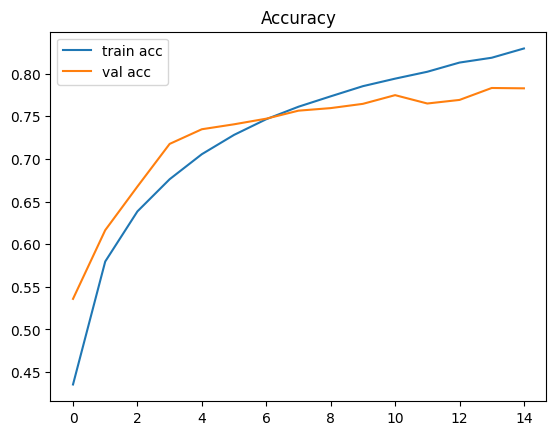

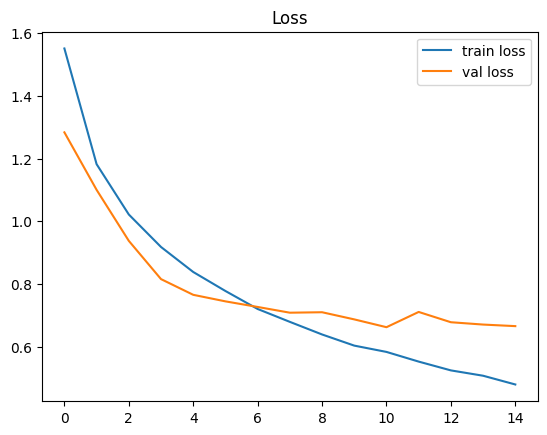

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

###  additional hands on practice
1. **Add BatchNormalization:** Add after each Conv:
    ```python
    layers.Conv2D(...),
    layers.BatchNormalization(),
    layers.ReLU(),
    ```
   - Observe smoother training.

2. **Try different optimizer**
   - Compare:
     1. SGD
     2. RMSprop
     3. Adam

3. **Add more filters**
   - 32 → 64 → 128 filters
   - Note accuracy change.

4. **Use EarlyStopping**
    ```python
    from tensorflow.keras.callbacks import EarlyStopping
    cb = EarlyStopping(patience=3, restore_best_weights=True)
    model.fit(..., callbacks=[cb])
    ```

5. **Visualize feature maps**
    ```python
    from tensorflow.keras import Model

    layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
    vis_model = Model(model.input, layer_outputs)
    feature_maps = vis_model.predict(x_train[:1])
    ```